In [1]:
!pip install ultralytics opencv-python matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.2 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
image_folder = "/content/sample_data/images"
label_folder = "/content/sample_data/label"

output_defog = "/content/defogged_images"
output_detect = "/content/detected_images"

import os
os.makedirs(output_defog, exist_ok=True)
os.makedirs(output_detect, exist_ok=True)

In [7]:
import cv2
import numpy as np

def dark_channel(img, size=15):
    min_channel = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    dark = cv2.erode(min_channel, kernel)
    return dark


def estimate_atmosphere(img, dark):
    h, w = img.shape[:2]
    num_pixels = int(max(h*w*0.001, 1))

    dark_vec = dark.reshape(h*w)
    img_vec = img.reshape(h*w,3)

    indices = dark_vec.argsort()[-num_pixels:]
    atmosphere = np.mean(img_vec[indices], axis=0)

    return atmosphere


def estimate_transmission(img, atmosphere, omega=0.95, size=15):
    norm_img = img / atmosphere
    transmission = 1 - omega * dark_channel(norm_img, size)
    return transmission


def recover_image(img, transmission, atmosphere, t0=0.1):
    transmission = np.maximum(transmission, t0)
    J = np.empty_like(img)

    for i in range(3):
        J[:,:,i] = (img[:,:,i] - atmosphere[i]) / transmission + atmosphere[i]

    return np.clip(J,0,255).astype(np.uint8)


def remove_fog_dcp(image):

    image = image.astype(np.float64)

    dark = dark_channel(image)
    atmosphere = estimate_atmosphere(image, dark)
    transmission = estimate_transmission(image, atmosphere)

    result = recover_image(image, transmission, atmosphere)

    return result

In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [8]:
import cv2
import os

for img_name in os.listdir(image_folder):

    img_path = os.path.join(image_folder, img_name)

    image = cv2.imread(img_path)

    if image is None:
        continue


    defogged = remove_fog_dcp(image)

    # Save defogged image
    cv2.imwrite(os.path.join(output_defog, img_name), defogged)

    # Step 2: Run YOLO detection
    results = model(defogged)

    annotated = results[0].plot()

    # Save detection output
    cv2.imwrite(os.path.join(output_detect, img_name), annotated)

print("Processing Completed")


0: 352x640 1 car, 1 bus, 140.3ms
Speed: 4.0ms preprocess, 140.3ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)

0: 384x640 1 car, 1 truck, 141.8ms
Speed: 3.6ms preprocess, 141.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 448x640 5 cars, 2 buss, 2 trucks, 175.0ms
Speed: 4.0ms preprocess, 175.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 352x640 3 persons, 6 cars, 127.4ms
Speed: 3.4ms preprocess, 127.4ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)

0: 448x640 2 persons, 5 cars, 2 trucks, 156.9ms
Speed: 3.2ms preprocess, 156.9ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 2 persons, 10 cars, 1 bus, 1 truck, 157.5ms
Speed: 4.4ms preprocess, 157.5ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 5 cars, 158.3ms
Speed: 3.9ms preprocess, 158.3ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 car, 173.5ms

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

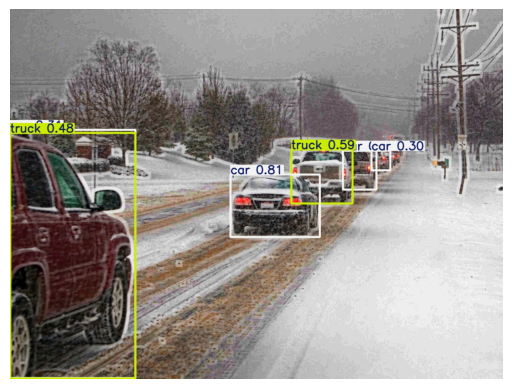

In [11]:
import matplotlib.pyplot as plt
import cv2

sample = os.listdir(output_detect)[8]

img = cv2.imread(os.path.join(output_detect, sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [12]:
!pip install scikit-image

In [13]:
import cv2
import os
import numpy as np
from skimage.metrics import structural_similarity as ssim

In [14]:
def calculate_psnr(original, processed):

    mse = np.mean((original - processed) ** 2)

    if mse == 0:
        return 100

    max_pixel = 255.0

    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return psnr


def calculate_mse(original, processed):

    mse = np.mean((original - processed) ** 2)

    return mse


def calculate_ssim(original, processed):

    original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    processed_gray = cv2.cvtColor(processed, cv2.COLOR_BGR2GRAY)

    score, _ = ssim(original_gray, processed_gray, full=True)

    return score

In [17]:
fog_folder = "/content/sample_data/images"
dehaze_folder = "/content/defogged_images"

In [18]:
psnr_list = []
ssim_list = []
mse_list = []

for img_name in os.listdir(fog_folder):

    fog_path = os.path.join(fog_folder, img_name)
    dehaze_path = os.path.join(dehaze_folder, img_name)

    fog = cv2.imread(fog_path)
    dehaze = cv2.imread(dehaze_path)

    if fog is None or dehaze is None:
        continue

    fog = cv2.resize(fog, (512,512))
    dehaze = cv2.resize(dehaze, (512,512))

    psnr_value = calculate_psnr(fog, dehaze)
    ssim_value = calculate_ssim(fog, dehaze)
    mse_value = calculate_mse(fog, dehaze)

    psnr_list.append(psnr_value)
    ssim_list.append(ssim_value)
    mse_list.append(mse_value)

print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))
print("Average MSE:", np.mean(mse_list))

Average PSNR: 28.161417151456035
Average SSIM: 0.6193990086345176
Average MSE: 103.35106827693495
